# Đề tài: Biểu diễn ngữ nghĩa và gom cụm văn bản báo chí tiếng Việt theo nhánh semantic

## Bối cảnh
Notebook 3 đã hoàn thành vai trò baseline cho nhánh lexical thông qua các pipeline TF-IDF và BM25 kết hợp với TruncatedSVD và K-Means. Kết quả cho thấy mô hình baseline đã đạt được một mức độ khớp nhất định với nhãn chuyên mục gốc, nhưng các chỉ số nội tại như Silhouette và Davies-Bouldin vẫn chưa đạt mức kỳ vọng. Điều này cho thấy biểu diễn dựa trên trọng số từ vẫn chưa đủ để làm rõ ranh giới cụm trong dữ liệu báo chí tiếng Việt.

## Mục tiêu
Notebook này tập trung vào việc xây dựng nhánh semantic nhằm biểu diễn văn bản ở mức ngữ nghĩa cao hơn, từ đó kỳ vọng cải thiện chất lượng gom cụm. Các mục tiêu chính gồm:
- sử dụng văn bản đã tiền xử lý từ Notebook 2 làm đầu vào,
- tạo embedding ngữ nghĩa cho từng bài báo,
- giảm chiều dữ liệu nếu cần,
- áp dụng thuật toán gom cụm phù hợp hơn với không gian semantic,
- và đánh giá kết quả bằng cả chỉ số có giám sát lẫn không giám sát.

## Ý nghĩa học thuật
Khác với nhánh lexical vốn phụ thuộc chủ yếu vào tần suất và trọng số từ, nhánh semantic cho phép biểu diễn văn bản theo ngữ nghĩa tiềm ẩn, giúp các bài báo có nội dung gần nhau được đặt gần nhau hơn trong không gian đặc trưng ngay cả khi không dùng hoàn toàn cùng từ vựng. Đây là hướng tiếp cận quan trọng để kiểm tra liệu dữ liệu báo chí tiếng Việt có thể được gom cụm tốt hơn khi chuyển từ biểu diễn bề mặt sang biểu diễn ngữ nghĩa hay không.

## Đầu ra mong đợi
Sau notebook này, đầu ra mong đợi gồm:
- ma trận embedding semantic cho toàn bộ tập văn bản,
- các phiên bản embedding đã giảm chiều nếu cần,
- kết quả gom cụm từ một hoặc nhiều thuật toán phù hợp với dữ liệu semantic,
- bảng đánh giá bằng NMI, ARI, Purity, Silhouette, Davies-Bouldin Index và Calinski-Harabasz,
- và cơ sở rõ ràng để chọn pipeline semantic tốt nhất cho bước phân tích cụm sau đó.

In [10]:
# Cell 2: import thư viện và khai báo đường dẫn dữ liệu cho Notebook 4
# Cell này chuẩn bị môi trường làm việc và xác định file đầu vào đã tiền xử lý từ Notebook 2.

import pandas as pd
import numpy as np
from pathlib import Path

#INPUT_PATH = Path("D:/BAI TEST/data/processed_data/bai_test_do_an_preprocessed.csv")
INPUT_PATH = Path("bai_test_do_an_preprocessed.csv")
OUTPUT_DIR = Path("processed_data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("File đầu vào:", INPUT_PATH)
print("Tồn tại:", INPUT_PATH.exists())

print("\nThư mục đầu ra:", OUTPUT_DIR)

File đầu vào: bai_test_do_an_preprocessed.csv
Tồn tại: True

Thư mục đầu ra: processed_data


In [11]:
# Cell 3: đọc file dữ liệu tiền xử lý và kiểm tra nhanh đầu vào cho nhánh semantic
# Cell này giúp xác nhận các cột văn bản dùng cho embedding đã sẵn sàng.

df = pd.read_csv(INPUT_PATH)

print("Kích thước dữ liệu:", df.shape)
print("\nCác cột hiện có:")
print(df.columns.tolist())

print("\nSố giá trị thiếu theo cột:")
display(df.isna().sum().to_frame("missing_count"))

print("\nMột vài dòng dữ liệu đầu vào:")
display(df[["doc_id", "category_clean", "cluster_text_clean", "cluster_text_segmented"]].head(3))

Kích thước dữ liệu: (8727, 9)

Các cột hiện có:
['doc_id', 'source', 'category_clean', 'published_date', 'url', 'cluster_text', 'cluster_text_clean', 'cluster_text_segmented', 'cluster_text_lexical']

Số giá trị thiếu theo cột:


,missing_count
doc_id,0
source,0
category_clean,0
published_date,0
url,0
cluster_text,0
cluster_text_clean,2
cluster_text_segmented,2
cluster_text_lexical,0



Một vài dòng dữ liệu đầu vào:


,doc_id,category_clean,cluster_text_clean,cluster_text_segmented
0,1,cong_nghe,làn sóng máy tính lượng tử sau cơn sốt ai . qu...,làn_sóng máy_tính lượng_tử sau cơn_sốt ai . qu...
1,2,cong_nghe,meta đưa ai vào messenger trả lời khách hàng 2...,meta đưa ai vào messenger trả_lời khách_hàng 2...
2,3,cong_nghe,hà tiên sử dụng trí tuệ nhân tạo phục vụ hành ...,hà_tiên sử_dụng trí_tuệ nhân_tạo phục_vụ hành_...


In [12]:
# Cell 4: làm sạch nhanh cột đầu vào cho nhánh semantic
# Cell này đảm bảo cột văn bản dùng để tạo embedding không bị thiếu và không có chuỗi rỗng.

df_work = df.copy()

df_work["cluster_text_clean"] = (
    df_work["cluster_text_clean"]
    .fillna("")
    .astype(str)
    .str.strip()
)

empty_clean_count = (df_work["cluster_text_clean"] == "").sum()

print("Kích thước dữ liệu làm việc:", df_work.shape)
print("Số dòng có cluster_text_clean rỗng:", empty_clean_count)

display(
    df_work[["doc_id", "category_clean", "cluster_text_clean"]].head(3)
)

Kích thước dữ liệu làm việc: (8727, 9)
Số dòng có cluster_text_clean rỗng: 2


,doc_id,category_clean,cluster_text_clean
0,1,cong_nghe,làn sóng máy tính lượng tử sau cơn sốt ai . qu...
1,2,cong_nghe,meta đưa ai vào messenger trả lời khách hàng 2...
2,3,cong_nghe,hà tiên sử dụng trí tuệ nhân tạo phục vụ hành ...


In [13]:
# Cell 5: loại bỏ các dòng không còn nội dung cho nhánh semantic
# Cell này bỏ các văn bản rỗng sau tiền xử lý để đảm bảo mọi embedding được tạo từ nội dung thực sự có nghĩa.

before_rows = len(df_work)

df_work = df_work[df_work["cluster_text_clean"] != ""].copy()

after_rows = len(df_work)

print("Số dòng trước khi loại văn bản rỗng:", before_rows)
print("Số dòng sau khi loại văn bản rỗng:", after_rows)
print("Số dòng đã loại:", before_rows - after_rows)

display(df_work[["doc_id", "category_clean", "cluster_text_clean"]].head(3))

Số dòng trước khi loại văn bản rỗng: 8727
Số dòng sau khi loại văn bản rỗng: 8725
Số dòng đã loại: 2


,doc_id,category_clean,cluster_text_clean
0,1,cong_nghe,làn sóng máy tính lượng tử sau cơn sốt ai . qu...
1,2,cong_nghe,meta đưa ai vào messenger trả lời khách hàng 2...
2,3,cong_nghe,hà tiên sử dụng trí tuệ nhân tạo phục vụ hành ...


In [14]:
# Cell 6: cài đặt và import mô hình embedding semantic
# Cell này chuẩn bị sentence-transformers để tạo embedding ngữ nghĩa cho toàn bộ tập văn bản.

try:
    from sentence_transformers import SentenceTransformer
    print("Đã import sentence-transformers thành công.")
except ImportError:
    !pip -q install sentence-transformers
    from sentence_transformers import SentenceTransformer
    print("Đã cài đặt và import sentence-transformers thành công.")

Đã import sentence-transformers thành công.


In [15]:
# Cell 7: tải model semantic và tạo embedding cho toàn bộ tập văn bản
# Cell này sinh vector ngữ nghĩa cho từng bài báo từ cột cluster_text_clean để dùng cho các bước giảm chiều và gom cụm phía sau.

import torch
import time

MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Thiết bị đang dùng:", device)
print("Đang tải model:", MODEL_NAME)

model = SentenceTransformer(MODEL_NAME, device=device)

texts = df_work["cluster_text_clean"].tolist()

print("\nĐang tạo embedding semantic... (quá trình này có thể mất vài phút)")
start_time = time.time()

X_semantic = model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

elapsed_time = time.time() - start_time

print(f"\nHoàn thành tạo embedding trong: {elapsed_time:.2f} giây")
print("Kích thước ma trận embedding:", X_semantic.shape)

Thiết bị đang dùng: cuda
Đang tải model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Đang tạo embedding semantic... (quá trình này có thể mất vài phút)


Batches:   0%|          | 0/273 [00:00<?, ?it/s]


Hoàn thành tạo embedding trong: 38.54 giây
Kích thước ma trận embedding: (8725, 384)


In [16]:
# Cell 8: giảm chiều embedding semantic bằng UMAP
# Cell này đưa embedding về không gian thấp hơn nhưng vẫn giữ mức an toàn tương đối,
# nhằm hỗ trợ clustering tốt hơn mà không nén quá sâu ngay từ đầu.

try:
    import umap
    print("Đã import umap thành công.")
except ImportError:
    !pip -q install umap-learn
    import umap
    print("Đã cài đặt và import umap thành công.")

import time

UMAP_COMPONENTS = 50

print(f"Đang giảm chiều embedding semantic xuống {UMAP_COMPONENTS} chiều bằng UMAP...")
start_time = time.time()

umap_reducer = umap.UMAP(
    n_neighbors=15,
    n_components=UMAP_COMPONENTS,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

X_semantic_umap = umap_reducer.fit_transform(X_semantic)

elapsed_time = time.time() - start_time

print(f"Hoàn thành trong: {elapsed_time:.2f} giây")
print("Kích thước dữ liệu sau UMAP:", X_semantic_umap.shape)

Đã import umap thành công.
Đang giảm chiều embedding semantic xuống 50 chiều bằng UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Hoàn thành trong: 71.96 giây
Kích thước dữ liệu sau UMAP: (8725, 50)


In [17]:
# Cell 9: khảo sát số cụm k trên nhánh semantic bằng nhiều chỉ số
# Cell này quét k từ 2 đến 12 để quan sát đồng thời cấu trúc cụm nội tại
# và mức độ khớp với nhãn chuyên mục gốc.

k_values = list(range(2, 13))
true_labels = df_work["category_clean"].values

results_list = []

print("Đang khảo sát k trên nhánh semantic...")
for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    labels = kmeans.fit_predict(X_semantic_umap)

    sil = silhouette_score(X_semantic_umap, labels)
    ari = adjusted_rand_score(true_labels, labels)
    nmi = normalized_mutual_info_score(true_labels, labels)

    results_list.append({
        "k": k,
        "Silhouette": round(sil, 4),
        "ARI": round(ari, 4),
        "NMI": round(nmi, 4)
    })

    print(f"k = {k:>2} | Silhouette = {sil:.4f} | ARI = {ari:.4f} | NMI = {nmi:.4f}")

semantic_k_survey_df = pd.DataFrame(results_list)
display(semantic_k_survey_df)

Đang khảo sát k trên nhánh semantic...
k =  2 | Silhouette = 0.5369 | ARI = 0.3275 | NMI = 0.4486
k =  3 | Silhouette = 0.5855 | ARI = 0.4391 | NMI = 0.5817
k =  4 | Silhouette = 0.6634 | ARI = 0.6517 | NMI = 0.6814
k =  5 | Silhouette = 0.6347 | ARI = 0.6817 | NMI = 0.6928
k =  6 | Silhouette = 0.6049 | ARI = 0.7693 | NMI = 0.7247
k =  7 | Silhouette = 0.5453 | ARI = 0.7106 | NMI = 0.6969
k =  8 | Silhouette = 0.5024 | ARI = 0.6374 | NMI = 0.6695
k =  9 | Silhouette = 0.5100 | ARI = 0.6020 | NMI = 0.6534
k = 10 | Silhouette = 0.4430 | ARI = 0.5606 | NMI = 0.6390
k = 11 | Silhouette = 0.3975 | ARI = 0.4749 | NMI = 0.6148
k = 12 | Silhouette = 0.3997 | ARI = 0.4762 | NMI = 0.6170


,k,Silhouette,ARI,NMI
0,2,0.5369,0.3275,0.4486
1,3,0.5855,0.4391,0.5817
2,4,0.6634,0.6517,0.6814
3,5,0.6347,0.6817,0.6928
4,6,0.6049,0.7693,0.7247
5,7,0.5453,0.7106,0.6969
6,8,0.5024,0.6374,0.6695
7,9,0.5100,0.6020,0.6534
8,10,0.4430,0.5606,0.6390
9,11,0.3975,0.4749,0.6148


### Nhận xét chọn số cụm k trên nhánh semantic

Kết quả trên nhánh semantic cho thấy chất lượng gom cụm đã cải thiện rõ rệt so với nhánh lexical. Silhouette Score tăng mạnh lên vùng từ khoảng `0.50` đến `0.66`, cho thấy các cụm trong không gian semantic sau UMAP đã tách biệt tốt hơn đáng kể. Đồng thời, các chỉ số đánh giá ngoài cũng tăng mạnh, đặc biệt tại `k = 6`.

Nếu xét theo khả năng khớp với nhãn chuyên mục gốc, cấu hình `k = 6` là lựa chọn phù hợp nhất vì đạt **ARI = 0.7693** và **NMI = 0.7247**, đều là giá trị cao nhất trong bảng khảo sát. Ngoài ra, Silhouette tại `k = 6` cũng đạt `0.6049`, cao hơn rất nhiều so với nhánh lexical trước đó. Điều này cho thấy biểu diễn semantic đã giúp dữ liệu hình thành cấu trúc cụm sát với chuyên mục thực tế hơn.

Vì bộ dữ liệu hiện có 6 chuyên mục gốc và mục tiêu của đồ án là vừa đánh giá cấu trúc cụm vừa đối chiếu với ground truth, cấu hình **Semantic Embedding + UMAP(50) + K-Means(k=6)** là ứng viên mạnh nhất để tiếp tục đánh giá sâu hơn ở bước tiếp theo.

In [19]:
# Cell 10: đánh giá đầy đủ cấu hình semantic tốt nhất tại k = 6
# Cell này chốt mô hình semantic baseline mạnh nhất và tính bộ chỉ số đầy đủ để so sánh với Notebook 3.

from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

K_FINAL = 6
true_labels = df_work["category_clean"].values

def purity_score(y_true, y_pred):
    contingency = pd.crosstab(pd.Series(y_true, name="true"), pd.Series(y_pred, name="pred"))
    return contingency.max(axis=0).sum() / contingency.values.sum()

kmeans_semantic = KMeans(
    n_clusters=K_FINAL,
    init="k-means++",
    n_init=10,
    random_state=42
)

labels_semantic = kmeans_semantic.fit_predict(X_semantic_umap)

semantic_result = pd.DataFrame([{
    "model": "Semantic Embedding + UMAP(50) + K-Means",
    "k": K_FINAL,
    "n_clusters_found": len(np.unique(labels_semantic)),
    "Silhouette": round(silhouette_score(X_semantic_umap, labels_semantic), 4),
    "ARI": round(adjusted_rand_score(true_labels, labels_semantic), 4),
    "NMI": round(normalized_mutual_info_score(true_labels, labels_semantic), 4),
    "Purity": round(purity_score(true_labels, labels_semantic), 4),
    "Davies_Bouldin": round(davies_bouldin_score(X_semantic_umap, labels_semantic), 4),
    "Calinski_Harabasz": round(calinski_harabasz_score(X_semantic_umap, labels_semantic), 4),
}])

display(semantic_result)

,model,k,n_clusters_found,Silhouette,ARI,NMI,Purity,Davies_Bouldin,Calinski_Harabasz
0,Semantic Embedding + UMAP(50) + K-Means,6,6,0.6049,0.7693,0.7247,0.8918,0.5549,28421.056641


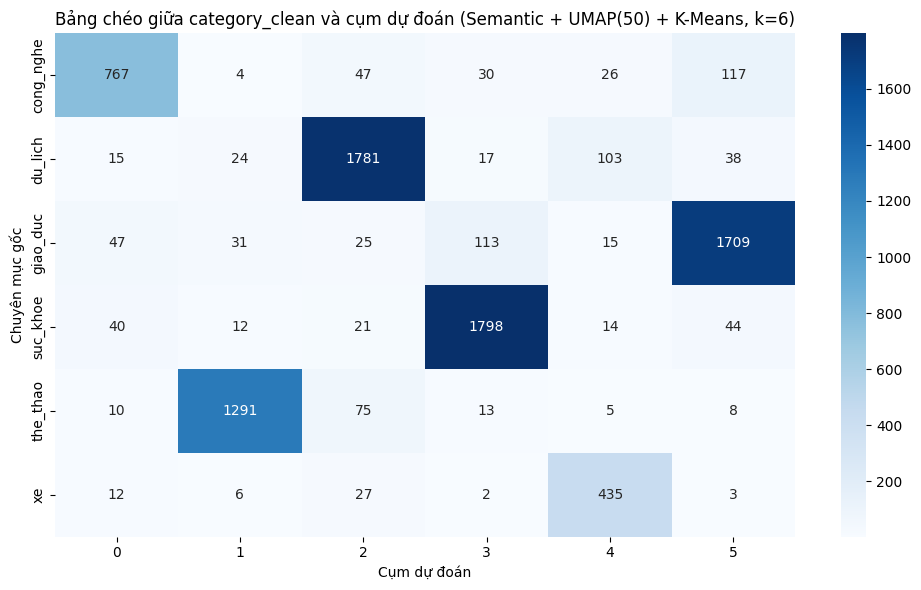

semantic_cluster_k6,0,1,2,3,4,5
category_clean,,,,,,
cong_nghe,767,4,47,30,26,117
du_lich,15,24,1781,17,103,38
giao_duc,47,31,25,113,15,1709
suc_khoe,40,12,21,1798,14,44
the_thao,10,1291,75,13,5,8
xe,12,6,27,2,435,3


In [20]:
# Cell 11: trực quan hóa bảng chéo giữa chuyên mục gốc và cụm dự đoán
# Cell này giúp quan sát cụm nào khớp tốt với ground truth và cụm nào còn bị trộn.

import matplotlib.pyplot as plt
import seaborn as sns

cluster_col = "semantic_cluster_k6"
df_work[cluster_col] = labels_semantic

crosstab_semantic = pd.crosstab(
    df_work["category_clean"],
    df_work[cluster_col]
)

plt.figure(figsize=(10, 6))
sns.heatmap(crosstab_semantic, annot=True, fmt="d", cmap="Blues")
plt.title("Bảng chéo giữa category_clean và cụm dự đoán (Semantic + UMAP(50) + K-Means, k=6)")
plt.xlabel("Cụm dự đoán")
plt.ylabel("Chuyên mục gốc")
plt.tight_layout()
plt.show()

display(crosstab_semantic)

### Nhận xét từ bảng chéo giữa chuyên mục gốc và cụm dự đoán

Bảng chéo cho thấy mô hình semantic đã tạo ra các cụm khá rõ và bám sát chuyên mục gốc. Nhiều chuyên mục có một cụm chiếm ưu thế rất mạnh, chẳng hạn `du_lich` tập trung chủ yếu vào cụm 2, `suc_khoe` vào cụm 3, `the_thao` vào cụm 1, `xe` vào cụm 4 và `giao_duc` vào cụm 5. Điều này cho thấy biểu diễn semantic đã giúp các bài báo cùng chủ đề được gom lại tốt hơn đáng kể.

Tuy nhiên, `cong_nghe` vẫn là chuyên mục khó hơn so với các nhóm còn lại, do còn một phần bài viết bị phân tán sang các cụm khác, đặc biệt là cụm 5. Điều này cho thấy nội dung công nghệ trong dữ liệu có mức độ giao thoa cao hơn với các chủ đề khác, nên ranh giới cụm chưa hoàn toàn tuyệt đối.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


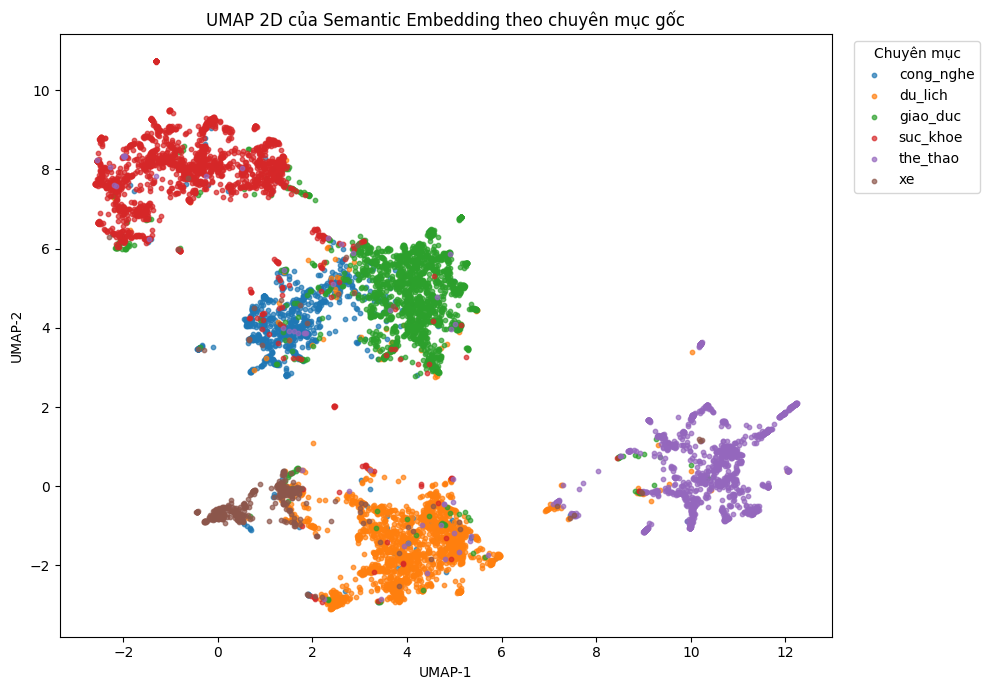

In [21]:
# Cell 12: trực quan hóa dữ liệu semantic trên mặt phẳng UMAP 2D theo chuyên mục gốc
# Cell này giúp quan sát trực quan mức độ tách biệt giữa các chuyên mục trong không gian semantic.

import matplotlib.pyplot as plt
import umap

umap_2d = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

X_semantic_2d = umap_2d.fit_transform(X_semantic)

plot_df = pd.DataFrame({
    "x": X_semantic_2d[:, 0],
    "y": X_semantic_2d[:, 1],
    "category_clean": df_work["category_clean"].values
})

plt.figure(figsize=(10, 7))

for category in sorted(plot_df["category_clean"].unique()):
    subset = plot_df[plot_df["category_clean"] == category]
    plt.scatter(
        subset["x"],
        subset["y"],
        s=10,
        alpha=0.7,
        label=category
    )

plt.title("UMAP 2D của Semantic Embedding theo chuyên mục gốc")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="Chuyên mục", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Nhận xét từ biểu đồ UMAP 2D theo chuyên mục gốc

Biểu đồ UMAP 2D cho thấy dữ liệu trong không gian semantic đã hình thành các vùng phân bố tương đối rõ theo chuyên mục. Một số nhóm như `the_thao`, `du_lich`, `suc_khoe` và `xe` tạo thành các cụm khá tách biệt, phản ánh rằng biểu diễn semantic đã giúp các văn bản cùng chủ đề nằm gần nhau hơn trong không gian đặc trưng.

Tuy nhiên, vẫn tồn tại một mức độ giao thoa nhất định giữa `cong_nghe` và `giao_duc`, cho thấy đây là các chuyên mục có nội dung gần nhau hơn hoặc dùng chung nhiều ngữ cảnh. Quan sát này phù hợp với kết quả định lượng và bảng chéo trước đó, trong đó `cong_nghe` là nhóm còn khó phân tách hơn so với các chuyên mục còn lại.


In [22]:
# Cell 13: tạo bảng so sánh cuối giữa nhánh lexical tốt nhất và nhánh semantic tốt nhất
# Cell này giúp chốt mô hình nào phù hợp hơn cho dữ liệu báo chí tiếng Việt.

comparison_df = pd.DataFrame([
    {
        "model": "BM25 + SVD(300) + K-Means",
        "k": 6,
        "Silhouette": 0.0269,
        "ARI": 0.5315,
        "NMI": 0.5862,
        "Purity": 0.7629,
        "Davies_Bouldin": 4.3216,
        "Calinski_Harabasz": 208.7923
    },
    {
        "model": "Semantic Embedding + UMAP(50) + K-Means",
        "k": 6,
        "Silhouette": 0.6049,
        "ARI": 0.7693,
        "NMI": 0.7247,
        "Purity": 0.8918,
        "Davies_Bouldin": 0.5549,
        "Calinski_Harabasz": 28421.0566
    }
])

display(comparison_df)

,model,k,Silhouette,ARI,NMI,Purity,Davies_Bouldin,Calinski_Harabasz
0,BM25 + SVD(300) + K-Means,6,0.0269,0.5315,0.5862,0.7629,4.3216,208.7923
1,Semantic Embedding + UMAP(50) + K-Means,6,0.6049,0.7693,0.7247,0.8918,0.5549,28421.0566
